# Projet de fouille de textes — Analyse de recettes de cuisine



**Objectif :**  
L’objectif de ce projet est d’analyser un corpus de recettes de cuisine à l’aide de méthodes de fouille de textes. Après un pré-traitement linguistique des textes, différentes représentations vectorielles sont construites afin d’appliquer une méthode de clustering non supervisée (K-means) et d’identifier des thématiques de recettes.

Les résultats sont évalués à l’aide de critères internes (méthode du coude, coefficient de silhouette) et de l’efficacité du système de recommandation basé sur les ingrédients et la similarité TF-IDF, mesurée via des métriques de ranking comme Recall@K et MRR.


In [2]:
import sys
print(sys.executable)


/opt/anaconda3_py310/bin/python


In [4]:
## Importation des differents packages

import pandas as pd
import numpy as np
import re
import spacy
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.cluster import KMeans
import spacy
import pickle
from pathlib import Path
import seaborn as sns
from sklearn.decomposition import TruncatedSVD

# Import des fonctions NLP
from nlp_fonctions import (
    normalize_text,
    clean_ingredients_regex,
    tokenize_text,
    spacy_pos_tag,
    lemmatize_tokens,
    extract_ingredients_final_row,
    nettoyer_liste_ingredients,
    tfidf_ingredients,
    top_ingredients,
    clean_title,
    top_terms_cluster,
    recommend_recipes,
    normalize_text_strict,
    recommend_by_cluster,
    recommend_weighted,
    culinary_chatbot_step1,
    culinary_chatbot_step2,
    evaluate_recommender
)


In [5]:
# ===============================
# 1. Chargement du jeu de données
# ===============================

data = pd.read_csv("recettes_marmiton.csv")

# ===============================
# 2. Normalisation des noms de colonnes
# ===============================

data.columns = data.columns.str.strip().str.lower()

# ===============================
# 3. Exploration rapide du dataset
# ===============================

data.shape


(9899, 12)

In [8]:
# ============================================
# Description générale du jeu de données
# ============================================

# Taille du jeu de données
print(f"Taille du jeu de données : {data.shape[0]} lignes et {data.shape[1]} colonnes.\n")

# Liste des colonnes disponibles
print("Colonnes disponibles dans le dataset :")
print(data.columns.tolist(), "\n")

# Types des variables
print("Types des variables (dtypes) :")
print(data.dtypes, "\n")

# Pourcentage de valeurs manquantes par colonne
print("Pourcentage de valeurs manquantes par colonne :")
print((data.isnull().mean() * 100).round(2), "\n")

# ============================================
# Suppression d'une variable non pertinente
# ============================================

print("Suppression de la colonne 'temps_repos' .")
data.drop(columns=["temps_repos"], inplace=True)

Taille du jeu de données : 9899 lignes et 12 colonnes.

Colonnes disponibles dans le dataset :
['titre', 'ingredients', 'etapes', 'difficulte', 'cout', 'personnes', 'temps_preparation', 'temps_cuisson', 'temps_repos', 'temps_total', 'image', 'url'] 

Types des variables (dtypes) :
titre                 object
ingredients           object
etapes                object
difficulte            object
cout                  object
personnes            float64
temps_preparation    float64
temps_cuisson        float64
temps_repos          float64
temps_total          float64
image                 object
url                   object
dtype: object 

Pourcentage de valeurs manquantes par colonne :
titre                 0.00
ingredients           0.00
etapes                0.00
difficulte            0.00
cout                  0.00
personnes             0.28
temps_preparation     2.65
temps_cuisson        16.28
temps_repos          91.89
temps_total           2.27
image                15.33
url      

In [10]:
# ============================================
# Application de la normalisation aux textes
# ============================================

# Normalisation des titres de recettes
data["titre_norm"] = data["titre"].apply(normalize_text)


# Vérification visuelle sur quelques exemples
data[["titre", "titre_norm"]].head()

,titre,titre_norm
0,Mousse au chocolat noir Nestlé Dessert®,mousse au chocolat noir nestlé dessert
1,Boulettes de fruits de mer au Airfryer,boulettes de fruits de mer au airfryer
2,Fusilli à la crème champignons et poulet,fusilli à la crème champignons et poulet
3,"Gaspacho vert, crabe et pamplemousse",gaspacho vert crabe et pamplemousse
4,Raviolis vapeur aux légumes,raviolis vapeur aux légumes


In [12]:
# ============================================
# Nettoyage des ingrédients par regex
# ============================================

# Adjectifs simples jugés peu informatifs pour l'identification des ingrédients
ADJECTIFS_SIMPLES = [
    "frais", "fraiche", "fraîche", "fraiches", "fraîches",
    "petit", "petite", "petits", "petites",
    "gros", "grosse", "grosses",
    "rouge", "rouges",
    "vert", "verte", "verts", "vertes",
    "blanc", "blanche", "blanches",
    "grand", "grande"
]

# Application du nettoyage aux ingrédients
data["ingredients_clean"] = data["ingredients"].apply(
    lambda x: clean_ingredients_regex(x, ADJECTIFS_SIMPLES)
)


# Vérification visuelle (avant / après)
data[["ingredients", "ingredients_clean"]].head()

,ingredients,ingredients_clean
0,"['1tablette chocolat NESTLÉ DESSERT Noir', '6 ...",tablette chocolat nestlé dessert noir oeufs pi...
1,"['480g crevette rose', '2cuillères à café huil...",crevette rose à café huile de sésame à café vi...
2,"['10g beurre', '3cubes Bouillon KUB® OR MAGGI®...",beurre cubes bouillon kub or maggi fusilli bla...
3,['2boîtes crabe en morceaux Nautilus® (égoutté...,boîtes crabe en morceaux nautilus égouttés feu...
4,"['200g champignons de Paris', '1 carotte', '10...",champignons de paris carotte épinards tofu à s...


In [14]:
# renommer les variables

df_final = data[
    ["titre_norm", "ingredients_clean", "etapes"]
].rename(columns={
    "titre_norm": "titre",
    "ingredients_clean": "ingredients",
    "etapes": "etapes"
})

#sauvegarde la base de données propres
df_final.to_csv("data/recettes_propres.csv", index=False)

In [16]:
# ============================================
# Chargement du jeu de données nettoyé
# ============================================

# Lecture du fichier CSV contenant les recettes prétraitées
# keep_default_na=False permet d'éviter que les chaînes vides
# soient interprétées automatiquement comme des valeurs NaN
df = pd.read_csv("data/recettes_propres.csv", keep_default_na=False)

# Vérification du contenu
df.head()

# Vérification optionnelle de la présence de valeurs manquantes

print((df.isnull().mean() * 100))


titre          0.0
ingredients    0.0
etapes         0.0
dtype: float64


Le jeu de données nettoyé est chargé à partir du fichier CSV final. Les chaînes vides issues des étapes de prétraitement sont conservées telles quelles et ne sont pas interprétées comme des valeurs manquantes, afin de faciliter les traitements linguistiques ultérieurs.

## Prétraitement avec Spacy

In [27]:
# ============================================
# Installation et chargement du modèle spaCy français
# ============================================

# Installation du modèle linguistique français (à exécuter une seule fois)
#!python -m spacy download fr_core_news_md

# Chargement du modèle spaCy français
nlp = spacy.load("fr_core_news_md")

In [28]:
# ============================================
# Application de la tokenisation aux ingrédients
# ============================================

# Création d'une nouvelle colonne contenant les tokens
df["ingredients_tokens"] = df["ingredients"].apply(tokenize_text)

# Vérification visuelle : ingrédients bruts vs tokens
df[["ingredients", "ingredients_tokens"]].head(10)

,ingredients,ingredients_tokens
0,tablette chocolat nestlé dessert noir oeufs pi...,"[tablette, chocolat, nestlé, dessert, noir, oe..."
1,crevette rose à café huile de sésame à café vi...,"[crevette, rose, café, huile, sésame, café, vi..."
2,beurre cubes bouillon kub or maggi fusilli bla...,"[beurre, cubes, bouillon, kub, maggi, fusilli,..."
3,boîtes crabe en morceaux nautilus égouttés feu...,"[boîtes, crabe, morceaux, nautilus, égouttés, ..."
4,champignons de paris carotte épinards tofu à s...,"[champignons, paris, carotte, épinards, tofu, ..."
5,tablette chocolat nestlé dessert crème liquide...,"[tablette, chocolat, nestlé, dessert, crème, l..."
6,aubergines oignon cébette à soupe sauce soja à...,"[aubergines, oignon, cébette, soupe, sauce, so..."
7,huile d olive filets de poisson bouquet basili...,"[huile, olive, filets, poisson, bouquet, basil..."
8,tranches jambon à étouffée le bon paris herta ...,"[tranches, jambon, étouffée, bon, paris, herta..."
9,beurre fondu farine sucre cacao en poudre oeuf...,"[beurre, fondu, farine, sucre, cacao, poudre, ..."


Les listes d’ingrédients sont ensuite tokenisées à l’aide de spaCy. Chaque recette est représentée par une liste de tokens filtrés, après suppression des mots vides et des termes peu informatifs. Cette représentation intermédiaire constitue la base des traitements linguistiques ultérieurs.

In [31]:
# Application du POS-tagging aux ingrédients tokenisés
df["ingredients_pos"] = df["ingredients_tokens"].apply(
    lambda tokens: spacy_pos_tag(tokens, nlp)
)


# Vérification visuelle
df[["ingredients_tokens", "ingredients_pos"]].head(10)

,ingredients_tokens,ingredients_pos
0,"[tablette, chocolat, nestlé, dessert, noir, oe...","[(tablette, NOUN), (chocolat, ADJ), (nestlé, V..."
1,"[crevette, rose, café, huile, sésame, café, vi...","[(crevette, NOUN), (rose, ADJ), (café, NOUN), ..."
2,"[beurre, cubes, bouillon, kub, maggi, fusilli,...","[(beurre, ADJ), (cubes, VERB), (bouillon, NOUN..."
3,"[boîtes, crabe, morceaux, nautilus, égouttés, ...","[(boîtes, NOUN), (crabe, NOUN), (morceaux, NOU..."
4,"[champignons, paris, carotte, épinards, tofu, ...","[(champignons, NOUN), (paris, PROPN), (carotte..."
5,"[tablette, chocolat, nestlé, dessert, crème, l...","[(tablette, NOUN), (chocolat, ADJ), (nestlé, V..."
6,"[aubergines, oignon, cébette, soupe, sauce, so...","[(aubergines, NOUN), (oignon, X), (cébette, NO..."
7,"[huile, olive, filets, poisson, bouquet, basil...","[(huile, NOUN), (olive, ADJ), (filets, NOUN), ..."
8,"[tranches, jambon, étouffée, bon, paris, herta...","[(tranches, NOUN), (jambon, PROPN), (étouffée,..."
9,"[beurre, fondu, farine, sucre, cacao, poudre, ...","[(beurre, ADJ), (fondu, VERB), (farine, NOUN),..."


In [33]:
from collections import Counter

# ============================================
# Identification des ingrédients fréquents
# ============================================

# Comptage de la fréquence de chaque token dans l'ensemble du corpus
counter = Counter(
    w
    for lst in df["ingredients_tokens"]
    for w in lst
)

# Sélection des termes apparaissant fréquemment dans le corpus

FREQ_ING = {w for w, c in counter.items() if c > 25}

print("Nombre d'ingrédients fréquents :", len(FREQ_ING))


# Liste d'ingrédients que l'on souhaite forcer comme noms
INGREDIENTS_FORCES = {
    "beurre", "farine", "sucre", "lait", "sel", "huile", "cacao", "poudre",
    "oeuf", "riz", "poulet", "chocolat", "pain", "vin", "café",
    "épice", "épices", "volaille", "calamar", "oignon", "châtaigne",
    "poivre", "pâte", "parmesan", "mozzarella", "ricotta",
    "crème", "saumon", "thon", "crevette", "sésame", "persil",
    "basilic", "menthe", "citron"
}

# Suffixes fréquents dans les noms d'ingrédients
CULINARY_SUFFIXES = (
    "ette", "ettes",
    "ure", "ures",
    "ine", "ines",
    "on", "ons",
    "ard", "ards",
    "ade", "ades"
)



# Application du POS-tagging corrigé aux ingrédients
df["ingredients_pos"] = df["ingredients_tokens"].apply(
    lambda tokens: spacy_pos_tag(
        token_list=tokens,
        nlp=nlp,
        frequent_terms=FREQ_ING,
        forced_ingredients=INGREDIENTS_FORCES,
        suffixes=CULINARY_SUFFIXES
    )
)

# Vérification visuelle
df[["ingredients_tokens", "ingredients_pos"]].head(10)


Nombre d'ingrédients fréquents : 638


,ingredients_tokens,ingredients_pos
0,"[tablette, chocolat, nestlé, dessert, noir, oe...","[(tablette, NOUN), (chocolat, NOUN), (nestlé, ..."
1,"[crevette, rose, café, huile, sésame, café, vi...","[(crevette, NOUN), (rose, NOUN), (café, NOUN),..."
2,"[beurre, cubes, bouillon, kub, maggi, fusilli,...","[(beurre, NOUN), (cubes, NOUN), (bouillon, NOU..."
3,"[boîtes, crabe, morceaux, nautilus, égouttés, ...","[(boîtes, NOUN), (crabe, NOUN), (morceaux, NOU..."
4,"[champignons, paris, carotte, épinards, tofu, ...","[(champignons, NOUN), (paris, NOUN), (carotte,..."
5,"[tablette, chocolat, nestlé, dessert, crème, l...","[(tablette, NOUN), (chocolat, NOUN), (nestlé, ..."
6,"[aubergines, oignon, cébette, soupe, sauce, so...","[(aubergines, NOUN), (oignon, NOUN), (cébette,..."
7,"[huile, olive, filets, poisson, bouquet, basil...","[(huile, NOUN), (olive, NOUN), (filets, NOUN),..."
8,"[tranches, jambon, étouffée, bon, paris, herta...","[(tranches, NOUN), (jambon, NOUN), (étouffée, ..."
9,"[beurre, fondu, farine, sucre, cacao, poudre, ...","[(beurre, NOUN), (fondu, NOUN), (farine, NOUN)..."


In [35]:
# ============================================
# Analyse de la cohérence du POS-tagging
# ============================================

# Dictionnaire : token -> ensemble des POS observés
pos_dict = defaultdict(set)

for lst in df["ingredients_pos"]:
    if isinstance(lst, list):
        for token, pos in lst:
            pos_dict[token].add(pos)

# Construction d'un DataFrame récapitulatif
pos_df = (
    pd.DataFrame([
        {
            "token": token,
            "pos_list": list(pos_list),
            "nb_pos": len(pos_list)
        }
        for token, pos_list in pos_dict.items()
    ])
    .sort_values("nb_pos", ascending=False)
)

# Affichage des tokens ayant le plus de variations de POS
pos_df.head(20)

,token,pos_list,nb_pos
1633,lin,"[PRON, NOUN, ADJ, DET, ADP, PROPN]",6
1992,wok,"[NOUN, VERB, ADJ, ADP, AUX]",5
2849,rosso,"[NOUN, VERB, ADJ, PUNCT, PROPN]",5
2020,negrita,"[NOUN, VERB, ADJ, PROPN, X]",5
766,worcestershire,"[NOUN, VERB, ADJ, DET, PROPN]",5
943,boursin,"[NOUN, ADJ, ADP, ADV, X]",5
304,conchiglioni,"[NOUN, VERB, AUX, PROPN, X]",5
485,moitié,"[NOUN, ADJ, DET, ADV, NUM]",5
1155,wraps,"[NOUN, PROPN, DET, ADJ]",4
855,restes,"[NOUN, VERB, ADJ, AUX]",4


In [37]:
# ============================================
# Analyse des incohérences résiduelles du POS-tagging
# ============================================

# Sélection des tokens associés à plusieurs catégories grammaticales
incoherents = pos_df[pos_df["nb_pos"] > 1]

# Affichage d'un sous-ensemble pour inspection manuelle
print(incoherents.iloc[30:60])

# Dimensions du tableau des incohérences
print("Nombre total de tokens incohérents :", incoherents.shape[0])

           token                  pos_list  nb_pos
707      travers     [ADV, NOUN, ADP, ADJ]       4
1273         dog      [ADJ, NOUN, VERB, X]       4
2650   champagne    [ADV, NOUN, VERB, ADJ]       4
1678    quantité  [PRON, NOUN, CCONJ, DET]       4
1991         tan    [PRON, NOUN, DET, ADJ]       4
1406    concassé         [NOUN, VERB, ADJ]       3
2891    réghalal          [VERB, ADP, ADJ]       3
1430    calamars           [NOUN, VERB, X]       3
1364     iceberg        [PROPN, NOUN, ADJ]       3
1468     serrano        [PROPN, VERB, AUX]       3
1367     saveurs          [ADV, NOUN, ADJ]       3
1373        fins             [ADV, ADJ, X]       3
2840         oro        [PROPN, VERB, ADJ]       3
2842   biologico           [DET, ADJ, AUX]       3
1386      fumées         [NOUN, VERB, ADJ]       3
1424     pétales          [ADV, NOUN, ADJ]       3
1387         dos          [NOUN, DET, ADJ]       3
334    complètes         [NOUN, VERB, ADJ]       3
1404      tahini          [ADV,

Les règles de correction améliorent globalement le POS-tagging, mais une ambiguïté
demeure pour certains termes dépendants du contexte. Dans ce cadre, le POS-tagging ne
peut pas servir de filtre strict lors de la lemmatisation et est utilisé avant tout à
des fins d’analyse, sans être intégré de manière contraignante au prétraitement final.


In [39]:
# Application de la lemmatisation aux ingrédients
df["ingredients_lemma"] = df["ingredients_tokens"].apply(lemmatize_tokens)

# Vérification visuelle
df[["ingredients_tokens", "ingredients_lemma"]].head(10)

,ingredients_tokens,ingredients_lemma
0,"[tablette, chocolat, nestlé, dessert, noir, oe...","[tablette, chocolat, nestler, desservir, noir,..."
1,"[crevette, rose, café, huile, sésame, café, vi...","[crevette, rose, café, huil, sésame, café, vin..."
2,"[beurre, cubes, bouillon, kub, maggi, fusilli,...","[beurr, cuber, bouillon, kub, maggi, fusilli, ..."
3,"[boîtes, crabe, morceaux, nautilus, égouttés, ...","[boîte, crabe, morceau, nautilu, égoutter, feu..."
4,"[champignons, paris, carotte, épinards, tofu, ...","[champignon, pari, carotte, épinard, tofu, sou..."
5,"[tablette, chocolat, nestlé, dessert, crème, l...","[tablette, chocolat, nestler, desservir, crème..."
6,"[aubergines, oignon, cébette, soupe, sauce, so...","[aubergine, oignon, cébette, soupe, sauce, soj..."
7,"[huile, olive, filets, poisson, bouquet, basil...","[huile, olive, filet, poisson, bouquet, basili..."
8,"[tranches, jambon, étouffée, bon, paris, herta...","[tranche, jambon, étouffé, bon, pari, herta, c..."
9,"[beurre, fondu, farine, sucre, cacao, poudre, ...","[beurr, fondre, farine, sucr, cacao, poudre, o..."


In [41]:
# ============================================
# Listes de filtrage (bruit non alimentaire)
# ============================================

# Faux ingrédients : formes, contenants, catégories
NON_ING = {
    "cuillère", "cuillères", "soupe", "café",
    "pincée", "pincées", "morceau", "morceaux",
    "pièce", "pièces", "poignée", "poignées",
    "feuille", "feuilles", "filet", "filets",
    "pousses", "fleurons", "préparation",
    "recette", "bocaux", "tasse", "conservation",
    "dessert"
}

# Adjectifs / états non alimentaires
ADJ_EXCLUDE = {
    "noir", "blanc", "rose", "vert", "jaune", "roux",
    "liquide", "fondu", "haché",
    "entier", "chimique", "nature",
    "brut", "fin", "râpé", "doux", "sec", "moulu",
    "non", "bien", "ancien", "amère"
}

# Marques
BRANDS = {
    "nestlé", "nautilus", "maggi", "bjorg", "herta",
    "président", "richesmonts", "kellogg",
    "bonneterre", "charal", "bonne", "maman"
}

# Ingrédients essentiels à toujours conserver
INGREDIENTS_FORCES = {
    "sel", "sucre", "beurre", "farine", "eau", "lait",
    "huile", "oeuf", "riz", "chocolat", "poulet",
    "poivre", "crème"
}

# Racines lexicales utiles
ROOTS = {
    "tomat", "légum", "fru", "herb", "oign",
    "poiss", "viand", "fromag", "pomm", "citron"
}



# ============================================
# Application de l'extraction finale des ingrédients
# ============================================

df["ingredients_final"] = df.apply(
    lambda row: extract_ingredients_final_row(
        row,
        NON_ING=NON_ING,
        BRANDS=BRANDS,
        ADJ_EXCLUDE=ADJ_EXCLUDE,
        INGREDIENTS_FORCES=INGREDIENTS_FORCES,
        ROOTS=ROOTS
    ),
    axis=1
)
# Comparaison avant / après extraction
df[["ingredients_tokens", "ingredients_final"]].head(20)

,ingredients_tokens,ingredients_final
0,"[tablette, chocolat, nestlé, dessert, noir, oe...","[tablette, chocolat, oeufs, sel]"
1,"[crevette, rose, café, huile, sésame, café, vi...","[crevette, huile, sésame, vin, chinois, épices..."
2,"[beurre, cubes, bouillon, kub, maggi, fusilli,...","[beurre, cubes, bouillon, kub, poulet, champig..."
3,"[boîtes, crabe, morceaux, nautilus, égouttés, ...","[boîtes, crabe, coriandre, zeste, pamplemousse..."
4,"[champignons, paris, carotte, épinards, tofu, ...","[champignons, paris, carotte, épinards, tofu, ..."
5,"[tablette, chocolat, nestlé, dessert, crème, l...","[tablette, chocolat, crème, poudre, cacao]"
6,"[aubergines, oignon, cébette, soupe, sauce, so...","[aubergines, oignon, cébette, sauce, soja, nuo..."
7,"[huile, olive, filets, poisson, bouquet, basil...","[huile, olive, poisson, bouquet, basilic, gous..."
8,"[tranches, jambon, étouffée, bon, paris, herta...","[tranches, jambon, bon, paris, riz, sauce, cac..."
9,"[beurre, fondu, farine, sucre, cacao, poudre, ...","[beurre, farine, sucre, cacao, poudre, oeufs, ..."


Bien que l’extraction finale des ingrédients permette déjà de filtrer une grande partie du bruit linguistique, cette étape ne suffit pas à garantir une représentation parfaitement homogène des recettes. Certains termes non alimentaires, tels que des ustensiles, des formes, des qualificatifs génériques ou des marques, peuvent encore subsister dans les listes d’ingrédients extraits.

Afin d’affiner davantage la qualité des données, un nettoyage final basé sur des listes de référence est mis en place. Des ingrédients essentiels sont explicitement conservés, tandis que des termes identifiés comme non pertinents pour la description culinaire sont exclus. Cette étape de raffinement permet de stabiliser le vocabulaire, d’améliorer la cohérence des ingrédients retenus et de préparer une représentation plus fiable pour les méthodes de vectorisation et de classification ultérieures.

In [44]:
# ============================================
# Listes de référence pour le nettoyage final
# ============================================

# Ingrédients à toujours conserver
INGREDIENTS_ALWAYS = {
    "sel","huile","poivre","sucre","beurre","farine","olive","crème","lait",
    "ail","poudre","levure","chocolat","eau","pâte","oeuf","citron","persil",
    "vanille","bouillon","jus","fromage","miel","vinaigre",
    "tomate","amande","riz","noix","basilic","poulet",
    "coriandre","parmesan","piment","soja","thym","coco","cannelle",
    "pomme","fraise","maïs","menthe","cacao","curry","noisette"
}

# Faux ingrédients : ustensiles, formes, adjectifs, marques, lieux
FAUX_INGREDIENTS = {

    # ustensiles
    "boîte", "boites", "bocal", "barquette", "verre",
    "bouteille", "casserole", "poêle", "bol", "saladier",
    "ramequin", "plat", "moule",

    # formes / unités
    "cuillère", "cuillères", "pincée", "pincées",
    "morceau", "morceaux", "poignée", "poignées",
    "filet", "filets", "branche", "brin",
    "tasse", "tasses", "tablette", "tablettes",

    # adjectifs / états non alimentaires
    "noir", "blanc", "rose", "vert", "jaune", "roux",
    "brut", "brute", "sec", "secs", "liquide",
    "épaisse", "épais", "haché", "hachée",
    "entier", "entière", "doux", "amère",
    "mou", "moue", "ancien", "ancienne",

    # qualificatifs génériques
    "bien", "bon", "non", "type",
    "alimentaire", "équivalent", "facultatif",
    "entièrement", "partiellement",

    # lieux
    "paris", "provence", "bretagne", "camargue",
    "bourgogne", "toulouse", "aucy",

    # marques
    "nestlé", "bjorg", "maggi", "nautilus", "herta",
    "président", "richesmonts", "bonneterre",
    "kellogg", "charal"
}

# Termes suspects (non bloquants, mais observés)
SUSPECTS = {
    "ambiante","alimentaire","équivalent","battu",
    "râpé","râpée","moulin","ancienne","type"
}

# ============================================
# Construction du vocabulaire global
# ============================================

# Vocabulaire issu de l'ensemble des ingrédients extraits
vocab = set(
    ing
    for lst in df["ingredients_final"]
    for ing in lst
)

# ============================================
# Nettoyage final des ingrédients
# ============================================

# Application des règles de nettoyage et de normalisation
df["ingredients_clean_final"] = df["ingredients_final"].apply(
    lambda lst: nettoyer_liste_ingredients(
        liste=lst,
        vocab=vocab,
        faux_ing=FAUX_INGREDIENTS,
        ingredients_always=INGREDIENTS_ALWAYS
    )
)


# Vérification visuelle avant / après normalisation
df[["ingredients_final", "ingredients_clean_final"]].head(20)


,ingredients_final,ingredients_clean_final
0,"[tablette, chocolat, oeufs, sel]","[chocolat, oeuf, sel]"
1,"[crevette, huile, sésame, vin, chinois, épices...","[crevette, huile, sésame, vin, chinois, épice,..."
2,"[beurre, cubes, bouillon, kub, poulet, champig...","[beurre, cube, bouillon, kub, poulet, champign..."
3,"[boîtes, crabe, coriandre, zeste, pamplemousse...","[boîte, crabe, coriandre, zeste, pamplemousse,..."
4,"[champignons, paris, carotte, épinards, tofu, ...","[champignon, carotte, épinard, tofu, sauce, so..."
5,"[tablette, chocolat, crème, poudre, cacao]","[chocolat, crème, poudre, cacao]"
6,"[aubergines, oignon, cébette, sauce, soja, nuo...","[aubergine, oignon, cébette, sauce, soja, nuoc..."
7,"[huile, olive, poisson, bouquet, basilic, gous...","[huile, olive, poisson, bouquet, basilic, gous..."
8,"[tranches, jambon, bon, paris, riz, sauce, cac...","[tranche, jambon, riz, sauce, cacahuète, oigno..."
9,"[beurre, farine, sucre, cacao, poudre, oeufs, ...","[beurre, farine, sucre, cacao, poudre, oeuf, l..."


##  Représentation Vectorielle (TF-IDF)

In [47]:
# ============================================
# Vectorisation TF-IDF (unigrammes)
# ============================================

X_uni, tfidf_uni, vec_uni = tfidf_ingredients(
    df,
    ngram_type="unigram"
)

# Vérification des dimensions
print("Shape :", tfidf_uni.shape)

# Aperçu de la matrice TF-IDF
tfidf_uni.head(10)

Shape : (9899, 499)


,abricot,agar,agave,agneau,aiguillette,ail,allumette,amande,ambiante,amer,...,yaourt,zeste,échalote,échine,épaule,épeautre,épice,épinard,érable,étoile
0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.146177,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.243619,0.000000,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.121979,0.0,0.0,0.0,0.0,...,0.0,0.217678,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.364947,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.146314,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.208937,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.233880,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0


In [49]:

# Analyse sur quelques recettes
print("Recette 1 :")
print(top_ingredients(tfidf_uni, 0, top_k=10))

print("\nRecette 2 :")
print(top_ingredients(tfidf_uni, 1, top_k=10))

print("\nRecette 3 :")
print(top_ingredients(tfidf_uni, 2, top_k=10))

Recette 1 :
chocolat    0.771002
oeuf        0.480515
sel         0.417924
Name: 0, dtype: float64

Recette 2 :
calamar      0.385380
chinois      0.361038
châtaigne    0.323708
crevette     0.270579
volaille     0.253070
épice        0.243619
sésame       0.237522
coriandre    0.216739
riz          0.210011
vin          0.209226
Name: 1, dtype: float64

Recette 3 :
kub           0.472929
tournesol     0.373680
champignon    0.318974
parmesan      0.317637
cube          0.314870
poulet        0.306821
persil        0.277015
bouillon      0.271573
crème         0.193802
beurre        0.170936
Name: 2, dtype: float64


In [51]:
# ============================================
# Vectorisation TF-IDF (bigrammes)
# ============================================

X_bi, tfidf_bi, vec_bi = tfidf_ingredients(
    df,
    ngram_type="bigram"
)

# Vérification des dimensions
print("Shape :", tfidf_bi.shape)

# Aperçu de la matrice TF-IDF
tfidf_bi.head(10)

Shape : (9899, 991)


,aiguillette poulet,ail basilic,ail botte,ail bouquet,ail champignon,ail citron,ail crème,ail céleri,ail eau,ail fine,...,échalote crème,échalote gousse,échalote oeuf,échalote oignon,échalote sel,échalote vin,échine porc,épaule agneau,épice sauce,étoile badiane
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [53]:
# ============================================
# Vectorisation TF-IDF (unigrammes + bigrammes)
# ============================================

X_both, tfidf_both, vec_both = tfidf_ingredients(
    df,
    ngram_type="both"
)

# Vérification des dimensions
print("Shape :", tfidf_both.shape)

# Aperçu de la matrice TF-IDF
tfidf_both.head(10)

Shape : (9899, 1490)


,abricot,agar,agave,agneau,aiguillette,aiguillette poulet,ail,ail basilic,ail botte,ail bouquet,...,échine porc,épaule,épaule agneau,épeautre,épice,épice sauce,épinard,érable,étoile,étoile badiane
0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.113899,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.189824,0.0,0.000000,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.095340,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.270877,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.108961,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.164424,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0


## Nuage de mot par importance

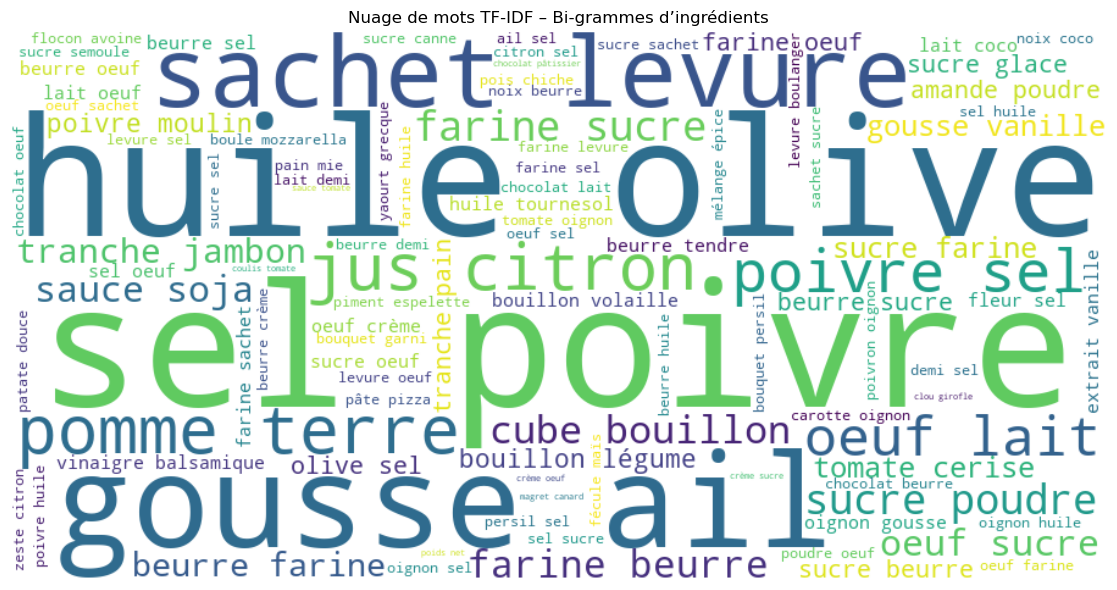

In [56]:
# ============================================
# Importance moyenne des bi-grammes (TF-IDF)
# ============================================

# Moyenne des poids TF-IDF sur l'ensemble des recettes
tfidf_bi_mean = tfidf_bi.mean(axis=0).sort_values(ascending=False)

# Sélection des 100 bi-grammes les plus importants
tfidf_bi_dict = tfidf_bi_mean.head(100).to_dict()

# ============================================
# Génération du nuage de mots
# ============================================
from wordcloud import WordCloud

wc = WordCloud(
    width=900,
    height=450,
    background_color="white",
    colormap="viridis"
).generate_from_frequencies(tfidf_bi_dict)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Nuage de mots TF-IDF – Bi-grammes d’ingrédients")
plt.tight_layout()
# Sauvegarde pour l'affichage
plt.savefig("logo/Nuage_mots.png")

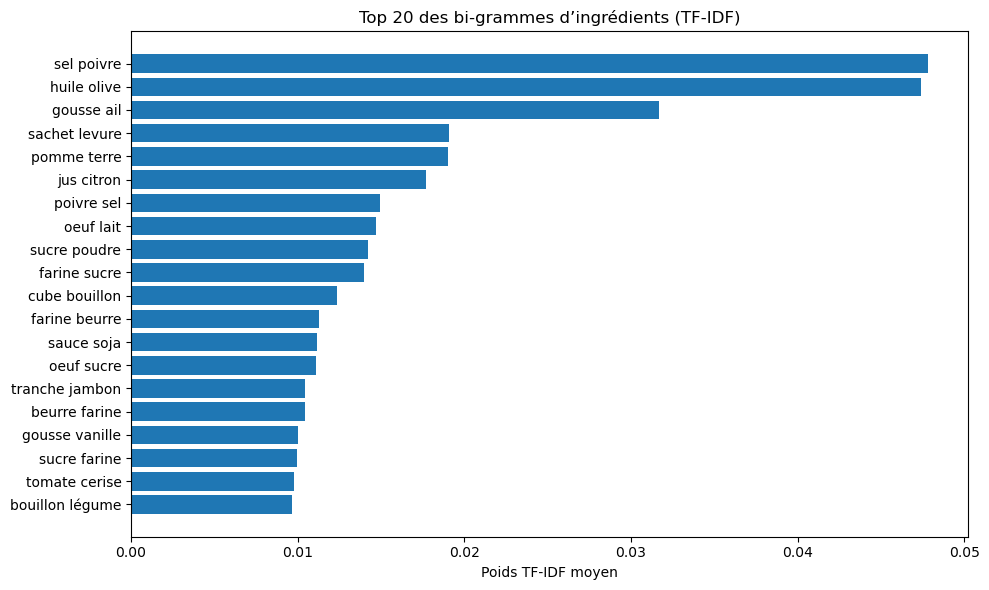

In [58]:
# ============================================
# Top bi-grammes selon le poids TF-IDF moyen
# ============================================

top_n = 20
top_terms = tfidf_bi_mean.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(
    top_terms.index[::-1],
    top_terms.values[::-1]
)
plt.xlabel("Poids TF-IDF moyen")
plt.title("Top 20 des bi-grammes d’ingrédients (TF-IDF)")
plt.tight_layout()

# 1. Sauvegarde
plt.savefig("logo/Histogram_bigram.png") 




## Classification non supervisée du Style Culinaire

En l’absence de labels de style culinaire et compte tenu de la taille importante du corpus (9 899 recettes), une approche de classification non supervisée a été retenue. Cette démarche vise à identifier des catégories culinaires latentes à partir des données disponibles, sans imposer de typologie préalable.

La classification repose sur une représentation TF-IDF construite à partir des ingrédients, éventuellement enrichie par les titres des recettes afin d’augmenter le pouvoir discriminant de la représentation. Les ingrédients décrivent la structure et la composition des plats, tandis que les titres apportent des mots-clés informatifs susceptibles de refléter des styles culinaires, des origines géographiques ou des types de préparation.

La méthode retenue est l’algorithme KMeans, appliqué à la représentation vectorielle TF-IDF. Cet algorithme permet de regrouper les recettes en clusters homogènes sur la base de leurs similarités, faisant émerger des styles culinaires implicites à partir des ingrédients et des termes associés, sans recours à une annotation préalable.

In [61]:
# Mots génériques peu informatifs
TITLE_STOPWORDS = {
    "recette", "dessert"
}

# ============================================
# Préparation du texte pour la classification KMeans
# ============================================

# Nettoyage des titres
df["titre_clean"] = df["titre"].apply(
    lambda x: clean_title(x, BRANDS, TITLE_STOPWORDS)
)

# Combinaison du titre nettoyé et des ingrédients
df["text_kmeans"] = (
    df["titre_clean"] + " " + df["ingredients_str"]
)

# Vérification
df.head()



,titre,ingredients,etapes,ingredients_tokens,ingredients_pos,ingredients_lemma,ingredients_final,ingredients_clean_final,ingredients_str,titre_clean,text_kmeans
0,mousse au chocolat noir nestlé dessert,tablette chocolat nestlé dessert noir oeufs pi...,"[""Faites fondre le chocolat cassé en petits mo...","[tablette, chocolat, nestlé, dessert, noir, oe...","[(tablette, NOUN), (chocolat, NOUN), (nestlé, ...","[tablette, chocolat, nestler, desservir, noir,...","[tablette, chocolat, oeufs, sel]","[chocolat, oeuf, sel]",chocolat oeuf sel,mousse au chocolat noir,mousse au chocolat noir chocolat oeuf sel
1,boulettes de fruits de mer au airfryer,crevette rose à café huile de sésame à café vi...,"[""Dans un robot ménager, ajoutez les crevettes...","[crevette, rose, café, huile, sésame, café, vi...","[(crevette, NOUN), (rose, NOUN), (café, NOUN),...","[crevette, rose, café, huil, sésame, café, vin...","[crevette, huile, sésame, vin, chinois, épices...","[crevette, huile, sésame, vin, chinois, épice,...",crevette huile sésame vin chinois épice volail...,boulettes de fruits de mer au airfryer,boulettes de fruits de mer au airfryer crevett...
2,fusilli à la crème champignons et poulet,beurre cubes bouillon kub or maggi fusilli bla...,['Faites cuire les pâtes dans un grand volume ...,"[beurre, cubes, bouillon, kub, maggi, fusilli,...","[(beurre, NOUN), (cubes, NOUN), (bouillon, NOU...","[beurr, cuber, bouillon, kub, maggi, fusilli, ...","[beurre, cubes, bouillon, kub, poulet, champig...","[beurre, cube, bouillon, kub, poulet, champign...",beurre cube bouillon kub poulet champignon par...,fusilli à la crème champignons et poulet,fusilli à la crème champignons et poulet beurr...
3,gaspacho vert crabe et pamplemousse,boîtes crabe en morceaux nautilus égouttés feu...,"['Pour le gaspacho vert :\nCouper les tomates,...","[boîtes, crabe, morceaux, nautilus, égouttés, ...","[(boîtes, NOUN), (crabe, NOUN), (morceaux, NOU...","[boîte, crabe, morceau, nautilu, égoutter, feu...","[boîtes, crabe, coriandre, zeste, pamplemousse...","[boîte, crabe, coriandre, zeste, pamplemousse,...",boîte crabe coriandre zeste pamplemousse huile...,gaspacho vert crabe et pamplemousse,gaspacho vert crabe et pamplemousse boîte crab...
4,raviolis vapeur aux légumes,champignons de paris carotte épinards tofu à s...,"['Hachez finement les champignons, la carotte,...","[champignons, paris, carotte, épinards, tofu, ...","[(champignons, NOUN), (paris, NOUN), (carotte,...","[champignon, pari, carotte, épinard, tofu, sou...","[champignons, paris, carotte, épinards, tofu, ...","[champignon, carotte, épinard, tofu, sauce, so...",champignon carotte épinard tofu sauce soja hui...,raviolis vapeur aux légumes,raviolis vapeur aux légumes champignon carotte...


Afin de construire une représentation textuelle adaptée à la classification non supervisée, les titres nettoyés sont combinés aux ingrédients prétraités de chaque recette. Les ingrédients décrivent la structure et la composition des plats, tandis que les titres apportent des mots-clés informatifs permettant de mieux distinguer les styles culinaires. Cette concaténation permet d’enrichir la représentation TF-IDF utilisée par l’algorithme KMeans et d’améliorer la séparation des clusters obtenus.

In [64]:
# ============================================
# Vectorisation TF-IDF pour le clustering KMeans
# ============================================

X, tfidf_df, vectorizerk = tfidf_ingredients(
    df,
    text_col="text_kmeans",
    ngram_type="both",   # unigrammes + bigrammes
    min_df=10            # filtrage des termes trop rares
)


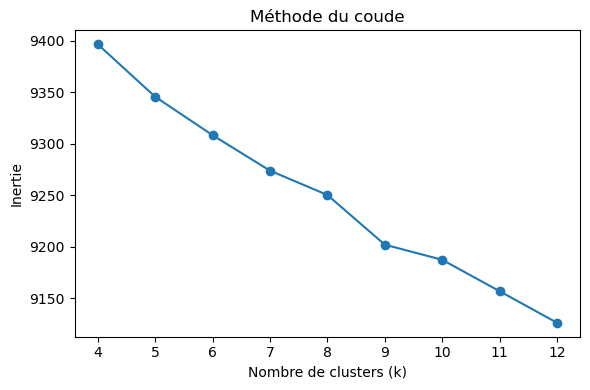

In [66]:
# ============================================
# Méthode du coude pour le choix de k
# ============================================

inertias = []
Ks = range(4, 13)   # plage raisonnable pour des styles culinaires

for k in Ks:
    km = KMeans(
        n_clusters=k,
        random_state=123,
        n_init=10
    )
    km.fit(X)      # X : matrice TF-IDF utilisée pour le clustering
    inertias.append(km.inertia_)

# Affichage 
list(zip(Ks, inertias))

# Visualisation
plt.figure(figsize=(6, 4))
plt.plot(Ks, inertias, marker="o")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie")
plt.title("Méthode du coude")
plt.tight_layout()
plt.show()

La méthode du coude ne fait pas apparaître de rupture nette. Un compromis raisonnable est observé autour de k = 7–9. Le choix de k = 8 a été retenu afin d’assurer un équilibre entre cohérence des clusters et interprétabilité thématique. 



In [73]:
# ============================================
# Entraînement du modèle KMeans final
# ============================================

k_final = 8

kmeans = KMeans(
    n_clusters=k_final,
    random_state=123,
    n_init=10
)

# Attribution du cluster à chaque recette
df["cluster"] = kmeans.fit_predict(X)

# Vérification
df.head()

,titre,ingredients,etapes,ingredients_tokens,ingredients_pos,ingredients_lemma,ingredients_final,ingredients_clean_final,ingredients_str,titre_clean,text_kmeans,cluster
0,mousse au chocolat noir nestlé dessert,tablette chocolat nestlé dessert noir oeufs pi...,"[""Faites fondre le chocolat cassé en petits mo...","[tablette, chocolat, nestlé, dessert, noir, oe...","[(tablette, NOUN), (chocolat, NOUN), (nestlé, ...","[tablette, chocolat, nestler, desservir, noir,...","[tablette, chocolat, oeufs, sel]","[chocolat, oeuf, sel]",chocolat oeuf sel,mousse au chocolat noir,mousse au chocolat noir chocolat oeuf sel,3
1,boulettes de fruits de mer au airfryer,crevette rose à café huile de sésame à café vi...,"[""Dans un robot ménager, ajoutez les crevettes...","[crevette, rose, café, huile, sésame, café, vi...","[(crevette, NOUN), (rose, NOUN), (café, NOUN),...","[crevette, rose, café, huil, sésame, café, vin...","[crevette, huile, sésame, vin, chinois, épices...","[crevette, huile, sésame, vin, chinois, épice,...",crevette huile sésame vin chinois épice volail...,boulettes de fruits de mer au airfryer,boulettes de fruits de mer au airfryer crevett...,6
2,fusilli à la crème champignons et poulet,beurre cubes bouillon kub or maggi fusilli bla...,['Faites cuire les pâtes dans un grand volume ...,"[beurre, cubes, bouillon, kub, maggi, fusilli,...","[(beurre, NOUN), (cubes, NOUN), (bouillon, NOU...","[beurr, cuber, bouillon, kub, maggi, fusilli, ...","[beurre, cubes, bouillon, kub, poulet, champig...","[beurre, cube, bouillon, kub, poulet, champign...",beurre cube bouillon kub poulet champignon par...,fusilli à la crème champignons et poulet,fusilli à la crème champignons et poulet beurr...,4
3,gaspacho vert crabe et pamplemousse,boîtes crabe en morceaux nautilus égouttés feu...,"['Pour le gaspacho vert :\nCouper les tomates,...","[boîtes, crabe, morceaux, nautilus, égouttés, ...","[(boîtes, NOUN), (crabe, NOUN), (morceaux, NOU...","[boîte, crabe, morceau, nautilu, égoutter, feu...","[boîtes, crabe, coriandre, zeste, pamplemousse...","[boîte, crabe, coriandre, zeste, pamplemousse,...",boîte crabe coriandre zeste pamplemousse huile...,gaspacho vert crabe et pamplemousse,gaspacho vert crabe et pamplemousse boîte crab...,6
4,raviolis vapeur aux légumes,champignons de paris carotte épinards tofu à s...,"['Hachez finement les champignons, la carotte,...","[champignons, paris, carotte, épinards, tofu, ...","[(champignons, NOUN), (paris, NOUN), (carotte,...","[champignon, pari, carotte, épinard, tofu, sou...","[champignons, paris, carotte, épinards, tofu, ...","[champignon, carotte, épinard, tofu, sauce, so...",champignon carotte épinard tofu sauce soja hui...,raviolis vapeur aux légumes,raviolis vapeur aux légumes champignon carotte...,4


In [75]:
# ============================================
# Association des recettes aux clusters
# ============================================

# Attribution des labels de cluster (une seule fois)
df["cluster"] = kmeans.labels_

# ============================================
# Analyse des mots dominants par cluster
# ============================================

# Termes du vocabulaire TF-IDF
terms = vectorizerk.get_feature_names_out()

# Centres des clusters
centroids = kmeans.cluster_centers_



for k in range(8):
    print(f"\nCluster {k} — mots dominants :")
    print(top_terms_cluster(centroids, terms, cluster_id=k, n=15))



Cluster 0 — mots dominants :
['canard', 'gras', 'foie gras', 'foie', 'magret', 'de canard', 'magret canard', 'de', 'poivre', 'magret de', 'sel poivre', 'sel', 'au', 'et', 'miel']

Cluster 1 — mots dominants :
['levure', 'farine', 'sachet', 'sachet levure', 'oeuf', 'sucre', 'beurre', 'lait', 'farine sucre', 'sel', 'oeuf lait', 'farine sachet', 'gâteau', 'poudre', 'farine beurre']

Cluster 2 — mots dominants :
['jambon', 'tranche', 'saumon', 'fromage', 'pâte', 'poivre', 'chèvre', 'tomate', 'sel', 'oeuf', 'au', 'pizza', 'tranche jambon', 'et', 'pain']

Cluster 3 — mots dominants :
['chocolat', 'au chocolat', 'sucre', 'oeuf', 'beurre', 'farine', 'au', 'lait', 'chocolat beurre', 'crème', 'poudre', 'chocolat lait', 'levure', 'amande', 'sachet']

Cluster 4 — mots dominants :
['poulet', 'sauce', 'soja', 'sauce soja', 'huile', 'oignon', 'de poulet', 'ail', 'de', 'poivre', 'poivron', 'au', 'riz', 'sésame', 'gingembre']

Cluster 5 — mots dominants :
['terre', 'pomme terre', 'pomme', 'de', 'de te

In [77]:
# ============================================
# Attribution d'un nom interprétable à chaque cluster
# ============================================

cluster_names = {
    0: "Desserts fruités et lactés",
    1: "Plats salés du quotidien",
    2: "Cuisine asiatique",
    3: "Plats italien",
    4: "Plats à base de pommes de terre",
    5: "Cuisine méditerranéenne",
    6: "Desserts chocolatés",
    7: "Pâtisserie et gâteaux de base"
}

# Création d'une colonne descriptive des clusters
df["cluster_name"] = df["cluster"].map(cluster_names)

# Vérification
df[["cluster", "cluster_name"]].head(10)


,cluster,cluster_name
0,3,Plats italien
1,6,Desserts chocolatés
2,4,Plats à base de pommes de terre
3,6,Desserts chocolatés
4,4,Plats à base de pommes de terre
5,3,Plats italien
6,4,Plats à base de pommes de terre
7,6,Desserts chocolatés
8,2,Cuisine asiatique
9,3,Plats italien


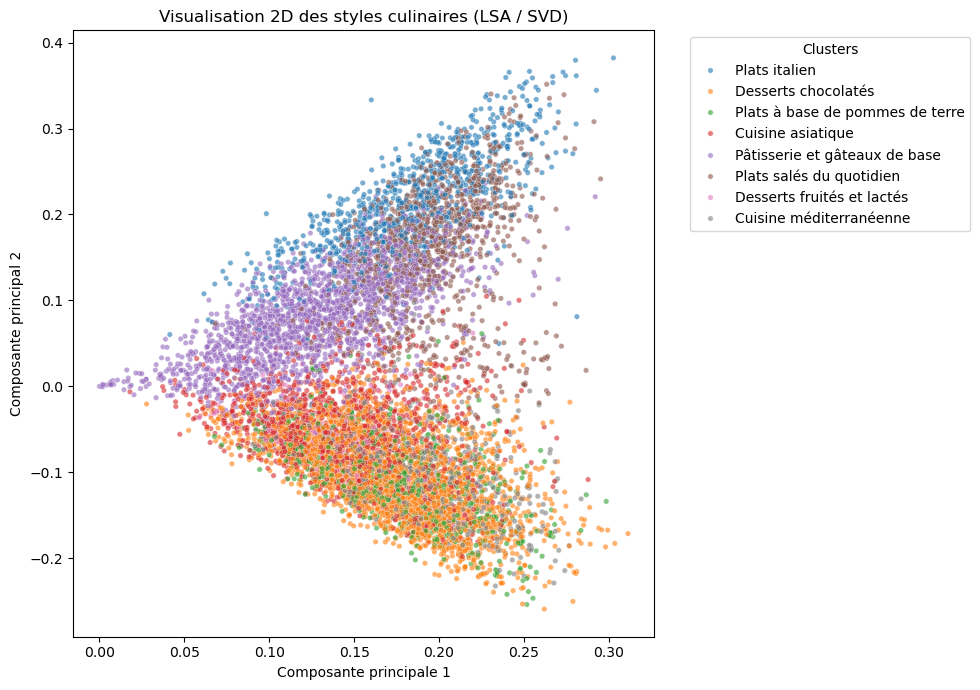

In [79]:

# Réduction de dimension (de milliers de mots à 2 axes X et Y)
svd = TruncatedSVD(n_components=2, random_state=42)
coords = svd.fit_transform(X) 

# Création d'un DataFrame temporaire pour le plot
df_plot = df.copy()
df_plot['x'] = coords[:, 0]
df_plot['y'] = coords[:, 1]

# Création du graphique
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_plot, 
    x='x', y='y', 
    hue='cluster_name',
    alpha=0.6,
    s=15
)

plt.title("Visualisation 2D des styles culinaires (LSA / SVD)")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principal 2")
plt.legend(title="Clusters", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Sauvegarde pour l'affichage
plt.savefig("logo/visualisation_2d_clusters.png")

La structure en éventail de la projection SVD valide la cohérence de la segmentation : les pôles opposés isolent parfaitement les desserts des plats salés, prouvant que les signatures lexicales du sucre et du gras sont mathématiquement discriminantes.

Le chevauchement partiel observé entre certains clusters (comme l'italien et le méditerranéen) n'est pas une erreur, mais le reflet logique de la proximité sémantique d'ingrédients partagés (huile d'olive, ail, aromates), montrant que l'algorithme capte les nuances culinaires réelles plutôt que de simples catégories étanches.

/tmp/ipykernel_7735/2561634501.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


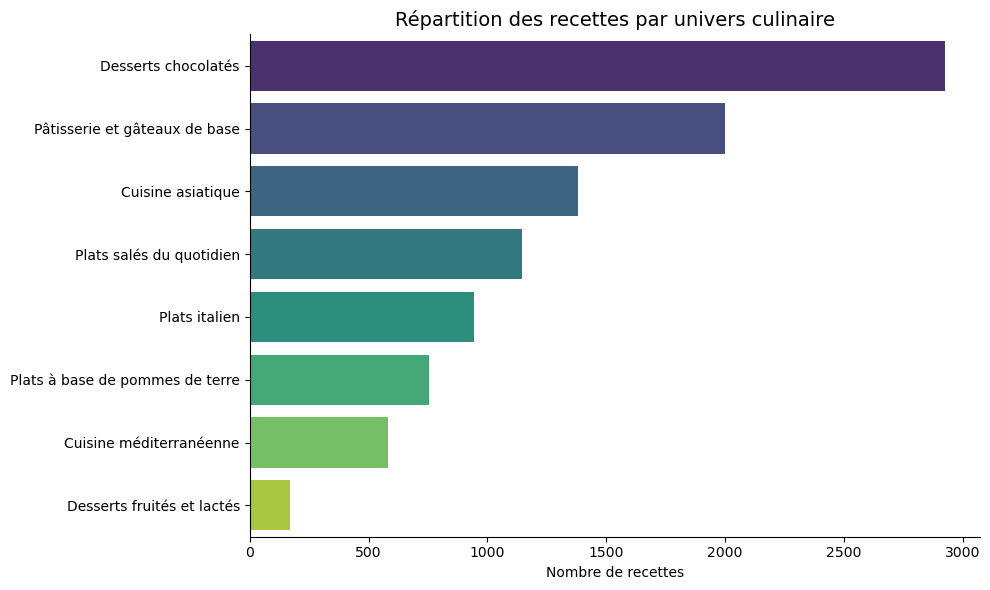

In [82]:
# Distribution des Clusters

# Préparation des données
cluster_counts = df['cluster_name'].value_counts().reset_index()
cluster_counts.columns = ['Style Culinaire', 'Nombre de Recettes']

# Création du graphique
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=cluster_counts, 
    y='Style Culinaire', 
    x='Nombre de Recettes', 
    palette='viridis', 
    ax=ax
)

ax.set_title("Répartition des recettes par univers culinaire", fontsize=14)
ax.set_xlabel("Nombre de recettes")
ax.set_ylabel("")
sns.despine()

# SAUVEGARDE DE L'IMAGE
plt.tight_layout()
plt.savefig("logo/distribution_clusters.png")

Notre base de données est largement dominé par le cluster des "Plats salés du quotidien" et celui des "Désserts fruités et lactés" avec près de 2 500 recettes, ce qui garantit une grande robustesse des recommandations pour les repas de tous les jours. À l'inverse, le style "Plats italien" est celui qui domine le moins avec environ 350 recettes.

## Recommandation des recettes
Recommandation de recettes à partir des ingrédients saisis

In [86]:
# ============================================
# Test de la recommandation basé uniquement sur la vectorisation
# ============================================

user_ingredients = ["riz", "sel", "poivre"]

recommendations = recommend_recipes(
    user_ingredients=user_ingredients,
    tfidf_matrix=tfidf_both,
    vectorizer=vec_both,
    df=df,
    top_k=5
)

recommendations[
    ["titre", "ingredients_clean_final", "n_common","cluster_name" ,"similarity", "score_final"]
]

,titre,ingredients_clean_final,n_common,cluster_name,similarity,score_final
3266,riz à l égyptienne au monsieur cuisine,"[riz, vermicelles, huile, olive, arôme, légume...",3,Desserts chocolatés,0.403247,0.403247
3267,riz à l égyptienne au companion,"[riz, vermicelles, huile, olive, arôme, légume...",3,Desserts chocolatés,0.403247,0.403247
3268,riz à l égyptienne au cooking chef,"[riz, vermicelles, huile, olive, arôme, légume...",3,Desserts chocolatés,0.403247,0.403247
3269,riz à l égyptienne au cookeo,"[riz, vermicelles, huile, olive, arôme, légume...",3,Desserts chocolatés,0.403247,0.403247
3262,riz à l égyptienne au thermomix,"[riz, vermicelles, huile, olive, arôme, légume...",3,Desserts chocolatés,0.403247,0.403247


In [88]:
# ============================================
# Test de la recommandation par cluster
# ============================================


# Création du nom de cluster normalisé 
df["cluster_name_norm"] = df["cluster_name"].apply(
    normalize_text_strict
)




recommendations_cluster = recommend_by_cluster(
    user_text="désserts Chocolates",
    df=df,
    top_k=5
)


# Affichage des résultats pertinents
recommendations_cluster[["titre", "cluster_name", "ingredients_clean_final"]]

,titre,cluster_name,ingredients_clean_final
1,boulettes de fruits de mer au airfryer,Desserts chocolatés,"[crevette, huile, sésame, vin, chinois, épice,..."
3,gaspacho vert crabe et pamplemousse,Desserts chocolatés,"[boîte, crabe, coriandre, zeste, pamplemousse,..."
7,filet de poisson grillé avec de la sauce pesto,Desserts chocolatés,"[huile, olive, poisson, bouquet, basilic, gous..."
15,boulettes de viande à la vapeur,Desserts chocolatés,"[viande, oignon, gousse, ail, oeuf, chapelure,..."
16,salade tiède de quinoa aux légumes vapeur,Desserts chocolatés,"[quinoa, eau, carotte, brocoli, poivron, huile..."


#### Recommandation de recettes combinant similarité et cluster

In [91]:
# ============================================
# Test de la recommandation pondérée
# ============================================

user_ingredients = ["riz", "sel", "poivre"]

recommendations_weighted = recommend_weighted(
    user_ingredients=user_ingredients,
    df=df,
    X_kmeans=X,
    vectorizerk=vectorizerk,
    kmeans=kmeans,
    alpha=0.75,
    top_k=5
)

recommendations_weighted[
    ["titre", "cluster_name", "ingredients_clean_final",
     "cosine_similarity", "cluster_score", "final_score"]
]

,titre,cluster_name,ingredients_clean_final,cosine_similarity,cluster_score,final_score
5527,onigiri,Desserts chocolatés,"[riz, sel, eau]",0.743156,1,0.807367
2931,cabillaud à la sauce korma patak s,Desserts chocolatés,"[poisson, cabillaud, pot, sauce, épinard, oign...",0.372583,1,0.529437
2628,gaspacho d asperges blanches et vinaigrette au...,Desserts chocolatés,"[asperge, cube, bouillon, légume, huile, sésam...",0.369953,1,0.527465
1498,poule au riz par laurent mariotte,Desserts chocolatés,"[beurre, clou, girofle, poule, carotte, poirea...",0.363652,1,0.522739
5781,blanquette de veau à l ancienne riz pilaf,Desserts chocolatés,"[épaule, veau, clou, girofle, oignon, carotte,...",0.350328,1,0.512746


## Chatbot Culinaire (Interaction)

In [94]:
# ============================================
# Construction du vocabulaire global des ingrédients
# ============================================

VOCAB_INGREDIENTS = set(
    ing
    for ingredients in df["ingredients_clean_final"]
    for ing in ingredients
)


# Colonnes numériques
numeric_cols = data.select_dtypes(include="number").columns.tolist()

# Colonnes spécifiques à ajouter
cols_to_add = ["cout", "difficulte", "image", "url"]

# Combinaison des deux listes sans doublons
selected_cols = list(set(numeric_cols + cols_to_add))


# Jointure CORRECTE sur titre et titre_norm
df_chatbot = df.merge(
    data[["titre_norm"] + selected_cols],
    left_on="titre",
    right_on="titre_norm",
    how="left"
)






# ============================
# TEST — Chatbot étape 1
# ============================

user_query = "J'ai du riz, sel et poivre dans mon placard"

recs, message = culinary_chatbot_step1(
    user_text=user_query,
    df_nlp=df,              # df utilisé pour la reco NLP
    df_chatbot=df_chatbot,      # df enrichi (temps, étapes, etc.)
    tfidf_matrix=tfidf_both,
    vectorizer=vec_both,
    vocab_ingredients=VOCAB_INGREDIENTS,
    top_k=5
)

print(message)

🧠 Ingrédients identifiés : riz, sel, poivre

🍽️ Voici les recettes les plus cohérentes :

1. **riz à l égyptienne au monsieur cuisine**
   👥 4 pers | ⏱️ 30 min | ⚙️ très facile

2. **riz à l égyptienne au companion**
   👥 4 pers | ⏱️ 30 min | ⚙️ très facile

3. **riz à l égyptienne au cooking chef**
   👥 4 pers | ⏱️ 30 min | ⚙️ très facile

4. **riz à l égyptienne au cookeo**
   👥 4 pers | ⏱️ 22 min | ⚙️ très facile

5. **riz à l égyptienne au thermomix**
   👥 4 pers | ⏱️ 30 min | ⚙️ très facile

👉 Écris le numéro de la recette pour voir les détails.


In [96]:
# ============================
# TEST — Chatbot étape 1
# ============================

# Étape 2
print(culinary_chatbot_step2(recs, "1"))

🍽️ **riz à l égyptienne au monsieur cuisine**

🧾 Ingrédients :
- riz
- vermicelles
- huile
- olive
- arôme
- légume
- sel
- poivre

👨‍🍳 Étapes de préparation :
1. Versez l’huile et les vermicelles dans la cuve de votre Monsieur Cuisine. Faites revenir, comme pour un riz pilaf pendant 6 min / vit. 2 / 105 °C / marche à gauche.
2. Ajoutez le riz et l’arôme de légumes, puis poursuivez la coloration pendant 2 min / vit. 2 / 95 °C / marche à gauche. Versez ensuite le tout dans le panier vapeur.
3. Ajoutez 50 cl d’eau, salez, poivrez et terminez la cuisson pendant 20 min / vit. 5 / 100 °C.

⏱️ Temps :
- Préparation : 10 min
- Cuisson : 20 min
- Total : 30 min

👥 Personnes : 4
⚙️ Difficulté : très facile
🖼️ Image : https://assets.afcdn.com/recipe/20191204/103405_w1024h768c1cx1927cy1227cxt0cyt0cxb3872cyb2592.jpg
🔗 Recette originale : https://www.marmiton.org/recettes/recette_riz-a-l-egyptienne-au-monsieur-cuisine_383523.aspx


In [98]:
## Sauvegarde des objets pour l'application de recette


MODELS_DIR = Path("models")  

with open(MODELS_DIR / "vec_both.pkl", "wb") as f:
    pickle.dump(vec_both, f)
with open(MODELS_DIR / "tfidf_both.pkl", "wb") as f:
    pickle.dump(tfidf_both, f)
with open(MODELS_DIR / "df.pkl", "wb") as f:
    pickle.dump(df, f)
with open(MODELS_DIR / "df_chatbot.pkl", "wb") as f:
    pickle.dump(df_chatbot, f)
with open(MODELS_DIR / "vocab_ingredients.pkl", "wb") as f:
    pickle.dump(VOCAB_INGREDIENTS, f)

## Evaluation de nos méthodes


In [101]:
results_tfidf = evaluate_recommender(
    df=df,  # df pour sampling
    recommend_func=lambda user_ingredients, top_k, tfidf_matrix=tfidf_both, vectorizer=vec_both: recommend_recipes(
        user_ingredients=user_ingredients,
        tfidf_matrix=tfidf_matrix,
        vectorizer=vectorizer,
        df=df,
        top_k=top_k
    ),
    top_k=5
)

results_tfidf

{'Recall@K': 0.8790650406504065, 'MRR': 0.7728150406504065}

Avec la configuration reproductible fixée par random_state=123, l’évaluation du système de recommandation basé sur la similarité TF-IDF des ingrédients montre un Recall@5 de 87,8 % et un MRR de 0,77. Cela signifie que dans plus de 8 cas sur 10, la recette originale est retrouvée parmi les 5 premières suggestions, et qu’elle est souvent bien classée dans le top du classement. Ces résultats confirment que la méthode est efficace pour proposer rapidement des recettes pertinentes, offrant ainsi une expérience utilisateur fiable et cohérente.

In [103]:
results_weighted = evaluate_recommender(
    df=df,  # df pour échantillonnage dans evaluate_recommender
    recommend_func=lambda user_ingredients, top_k: recommend_weighted(
        user_ingredients=user_ingredients,
        df=df,
        X_kmeans=X,
        vectorizerk=vectorizerk,
        kmeans=kmeans,
        alpha=0.75,
        top_k=top_k
    ),
    top_k=5
)

results_weighted


{'Recall@K': 0.6290650406504065, 'MRR': 0.4996951219512195}

 L’évaluation de la méthode recommend_weighted, qui combine la similarité TF-IDF des ingrédients et un bonus basé sur l’appartenance au même cluster, montre un Recall@5 de 61 % et un MRR de 0,49. Cela signifie que la recette originale est retrouvée dans le Top‑5 dans environ 6 cas sur 10 et qu’elle est moins souvent bien classée (position moyenne plus éloignée de la première place) comparé à la méthode TF-IDF pure. Ces résultats suggèrent que l’ajout du facteur cluster n’améliore pas la récupération des recettes pertinentes dans cette configuration et que la similarité directe par ingrédients reste plus performante pour cet ensemble de données.